Usualmente, cuando tenemos datos tabulares, analizamos columnas con números y categorías directas. En este caso al tratar con imágenes, el EDA implica explorar propiedades visuales, espaciales y geométricas (como píxeles, colores y formas) que primero debemos extraer de los archivos de manera numérica. **A continuación, procederemos a evaluar estas características a través de las siguientes cinco características clave:**

## Librerías

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from scipy import interpolate
from sklearn.linear_model import LinearRegression

COLOR_PRIMARY = '#FF5E8A'
COLOR_SECONDARY = '#FF8FAB'
COLOR_TERTIARY = '#FFB7C9'
COLOR_DARK = '#D43F6B'
COLOR_LIGHT = '#FFE4EC'
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_TERTIARY, COLOR_DARK, '#FF6B9D', '#FF7FAA']

sns.set_style("whitegrid")
sns.set_palette(PALETTE)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [4]:
project_root = Path.cwd().parent
BASE_DIR = project_root / "data"
ANNOTATIONS_DIR = BASE_DIR / "annotations"
METADATA_CSV = ANNOTATIONS_DIR / "fruit_metadata.csv"

df = pd.read_csv(METADATA_CSV)
print(f"Total de recortes: {len(df)}")
print(f"Columnas disponibles: {df.columns.tolist()}")
df.head()

Total de recortes: 29827
Columnas disponibles: ['original_image', 'quality', 'fruit', 'crop_path', 'x', 'y', 'width_px', 'height_px', 'area_px', 'aspect_ratio', 'num_fruits_in_image', 'relative_size_in_image', 'coverage_ratio', 'img_width', 'img_height']


,original_image,quality,fruit,crop_path,x,y,width_px,height_px,area_px,aspect_ratio,num_fruits_in_image,relative_size_in_image,coverage_ratio,img_width,img_height
0,good/apple_good/20190809_161113.jpg,good,apple,processed/good/apple/20190809_161113_crop0.jpg,72,18,184,179,32936,1.027933,1,1.0,0.502563,256,256
1,good/apple_good/20190812_185106.jpg,good,apple,processed/good/apple/20190812_185106_crop0.jpg,68,83,102,98,9996,1.040816,1,1.0,0.152527,256,256
2,good/apple_good/foto_177.jpg,good,apple,processed/good/apple/foto_177_crop0.jpg,479,193,607,588,356916,1.032313,1,1.0,0.172124,1920,1080
3,good/apple_good/20190809_122535.jpg,good,apple,processed/good/apple/20190809_122535_crop0.jpg,32,76,165,162,26730,1.018519,1,1.0,0.407867,256,256
4,good/apple_good/IMG20200728181038.jpg,good,apple,processed/good/apple/IMG20200728181038_crop0.jpg,95,75,62,72,4464,0.861111,2,1.0,0.090820,192,256


## 1. Etiquetas y desbalance de clases

En esta sección vamos a analizar cómo se distribuyen nuestras imágenes según el tipo de fruta y su estado de calidad. El objetivo es calcular el conteo exacto de cada combinación y medir el índice de imbalance ($IR$) para identificar si hay categorías con muy pocas fotos. Esto nos advertirá si el modelo corre el riesgo de ignorar las clases minoritarias, permitiéndonos planear estrategias de balanceo antes del entrenamiento.

In [8]:
freq_table = pd.crosstab(df['fruit'], df['quality'], margins=True)
freq_table_pct = pd.crosstab(df['fruit'], df['quality'], normalize='index') * 100

print("FRECUENCIA ABSOLUTA")
print(freq_table)
print("\nFRECUENCIA RELATIVA (%)")
print(freq_table_pct.round(2))

ir_values = []
for fruit in df['fruit'].unique():
    fruit_data = df[df['fruit'] == fruit]
    class_counts = fruit_data['quality'].value_counts()
    if len(class_counts) > 1:
        ir = class_counts.max() / class_counts.min()
    else:
        ir = 1
    ir_values.append({'fruit': fruit, 'IR': ir, 'max_class': class_counts.idxmax(), 'min_class': class_counts.idxmin()})

ir_df = pd.DataFrame(ir_values)
print("\nIMBALANCE RATIO POR FRUTA")
print(ir_df)
print(f"\nFrutas con IR > 3: {ir_df[ir_df['IR'] > 3]['fruit'].tolist()}")

FRECUENCIA ABSOLUTA
quality        bad   good  regular    All
fruit                                    
apple         1460   1564      499   3523
banana        1653   1148     1051   3852
guava         1840   1572      760   4172
lime          1247   1537      395   3179
orange        1338   1600      286   3224
pomegranate   3808   7545      524  11877
All          11346  14966     3515  29827

FRECUENCIA RELATIVA (%)
quality        bad   good  regular
fruit                             
apple        41.44  44.39    14.16
banana       42.91  29.80    27.28
guava        44.10  37.68    18.22
lime         39.23  48.35    12.43
orange       41.50  49.63     8.87
pomegranate  32.06  63.53     4.41

IMBALANCE RATIO POR FRUTA
         fruit         IR max_class min_class
0        apple   3.134269      good   regular
1       banana   1.572788       bad   regular
2        guava   2.421053       bad   regular
3         lime   3.891139      good   regular
4       orange   5.594406      good   re

El análisis de distribución revela un desbalance de clases crítico: 

- Aunque frutas como el banano y la guayaba tienen una distribución relativamente uniforme (con un $IR$ bajo de 1.57 en el caso del banano), la categoría de fruta regular es una minoría extrema en casi todo el dataset, representando menos del 10% en naranjas y granadas (pomegranate).
- Este comportamiento se evidencia drásticamente en las granadas, que concentran la gran mayoría de las muestras globales (11,877 imágenes) y disparan su Índice de Imbalance a un preocupante $IR = 14.40$, seguidas por la naranja con un $IR = 5.59$, y las manzanas y limones superando el límite crítico de $IR > 3$. 
- Si entrenamos los modelos con este sesgo, las redes neuronales y los algoritmos tradicionales tenderán a ignorar la clase regular y a predecir casi siempre good o bad para optimizar su accuracy (precisión global), por lo que será obligatorio aplicar técnicas de balanceo focalizado en las clases minoritarias o ajustar los pesos de la función de pérdida durante el modelado.

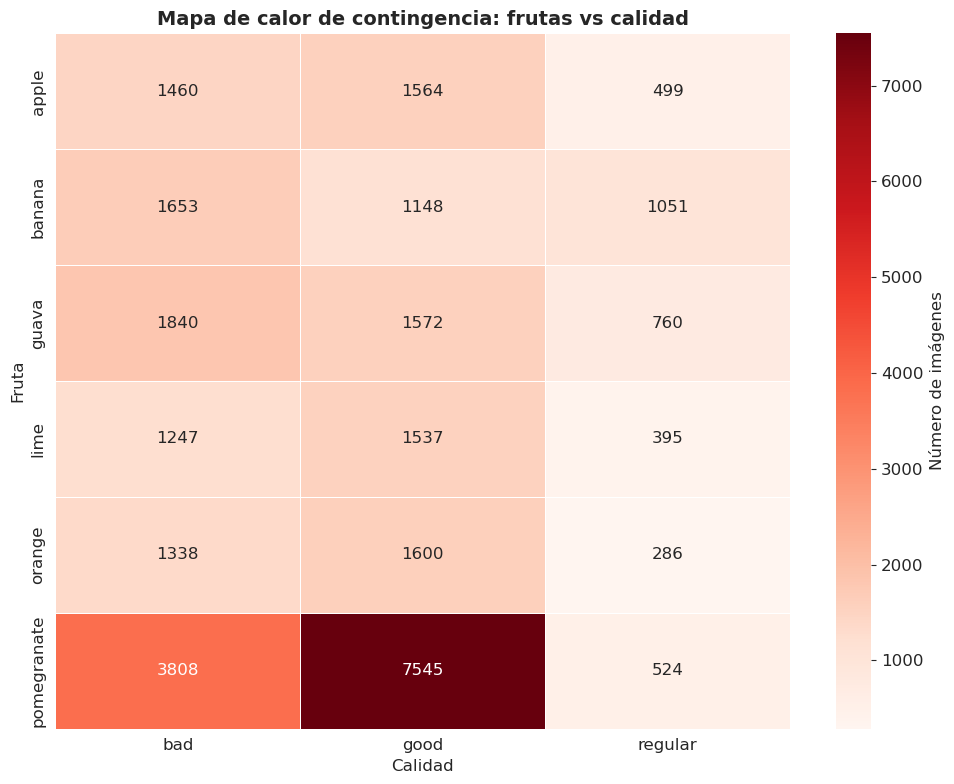

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
heatmap_data = pd.crosstab(df['fruit'], df['quality'])
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Reds', 
            linewidths=0.5, ax=ax, 
            cbar_kws={'label': 'Número de imágenes'})
ax.set_title('Mapa de calor de contingencia: frutas vs calidad', fontsize=14, fontweight='bold')
ax.set_xlabel('Calidad', fontsize=12)
ax.set_ylabel('Fruta', fontsize=12)
plt.tight_layout()
plt.show()

El mapa de calor de contingencia expone inmediatamente que el dataset está inundado por una sola fruta: la granada (pomegranate). 

El bloque de granadas de buena calidad (good) contiene 7,545 imágenes, una cifra que por sí sola supera la suma de todas las muestras de cualquier otra fruta del dataset (por ejemplo, el total de manzanas es de 3,523), lo que significa que cualquier red neuronal entrenada con estos datos sin procesar aprenderá a identificar granadas con un sesgo masivo.

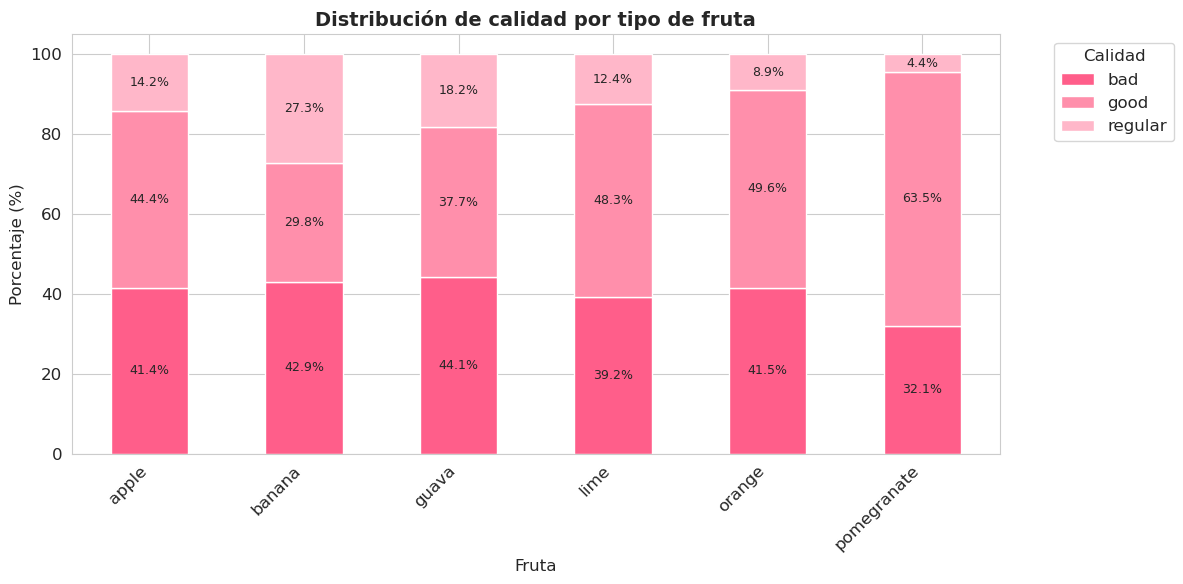

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
df_percent = pd.crosstab(df['fruit'], df['quality'], normalize='index') * 100
df_percent.plot(kind='bar', stacked=True, ax=ax, color=PALETTE[:3])
ax.set_title('Distribución de calidad por tipo de fruta', fontsize=14, fontweight='bold')
ax.set_xlabel('Fruta', fontsize=12)
ax.set_ylabel('Porcentaje (%)', fontsize=12)
ax.legend(title='Calidad', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9)
plt.tight_layout()
plt.show()

Al normalizar los datos al 100%, como dijimos anteriormente, se observa que la calidad regular (representada con el rosa más claro) es sistemáticamente la minoría en todas las especies. La situación es especialmente crítica en la naranja (orange) con un 8.9% y en la granada (pomegranate) donde cae a un minúsculo 4.4%. Un punto interesante es que para el resto de las frutas, a excepción de la granada, las categorías bad y good mantienen un equilibrio competitivo muy sano, rondando casi siempre entre el 30% y el 48% cada una.

## 2. Tamaño y forma

En esta sección, analizaremos el área en píxeles (area_px) y la relación de aspecto (aspect_ratio) de las frutas para entender su geometría y variabilidad. Esto servirá para definir los umbrales (puntos de corte) numéricos exactos que usaremos en el código para clasificar automáticamente las frutas en tamaño pequeño, mediano o grande.

In [14]:
stats_by_fruit = df.groupby('fruit')['area_px'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max',
    ('q25', lambda x: x.quantile(0.25)),
    ('q75', lambda x: x.quantile(0.75)),
    ('iqr', lambda x: x.quantile(0.75) - x.quantile(0.25))
]).round(2)

print("ESTADÍSTICAS DE ÁREA POR FRUTA")
print(stats_by_fruit)


ESTADÍSTICAS DE ÁREA POR FRUTA
             count        mean   median         std   min       max       q25  \
fruit                                                                           
apple         3523    84343.67  16000.0   452779.08   992  11442816   8154.00   
banana        3852    56603.87  36808.0   144358.53  1350   2073600   9102.50   
guava         4172    62462.92  31005.0   151079.86   930   1228800   8918.00   
lime          3179   161358.50  32757.0   453145.87  2021   2911932  19434.00   
orange        3224   173560.48  46439.0   485345.89  3078   2073600  32759.25   
pomegranate  11877  1724393.89  49152.0  5179927.58  2209  48000000  15470.00   

                 q75       iqr  
fruit                           
apple        30261.0  22107.00  
banana       56924.5  47822.00  
guava        58823.0  49905.00  
lime         40896.0  21462.00  
orange       65536.0  32776.75  
pomegranate  65536.0  50066.00  


El análisis morfológico del área (area_px) muestra una disparidad gigantesca entre los promedios y las medianas de todas las frutas, lo que delata una distribución fuertemente sesgada por valores atípicos muy grandes.

- El caso más extremo es la granada (pomegranate), con un área promedio de más de 1.7 millones de píxeles pero una mediana de apenas 49,152, alcanzando un valor máximo de 48 millones de píxeles. Esta enorme diferencia, sumada a desviaciones estándar que duplican o triplican a las medias, confirma que el dataset mezcla imágenes de resoluciones base muy distintas (fotos gigantescas de celulares modernos frente a miniaturas de Kaggle).
- Como el 75% de las muestras (q75) de casi todas las especies se estabiliza en un rango similar (entre 30,000 y 65,536 píxeles), se concluye que no se pueden usar los píxeles crudos para definir los tamaños (pequeño, mediano, grande); obligatoriamente se deberá normalizar el área calculando su porcentaje de ocupación sobre el lienzo total de la imagen antes de establecer los umbrales de corte.

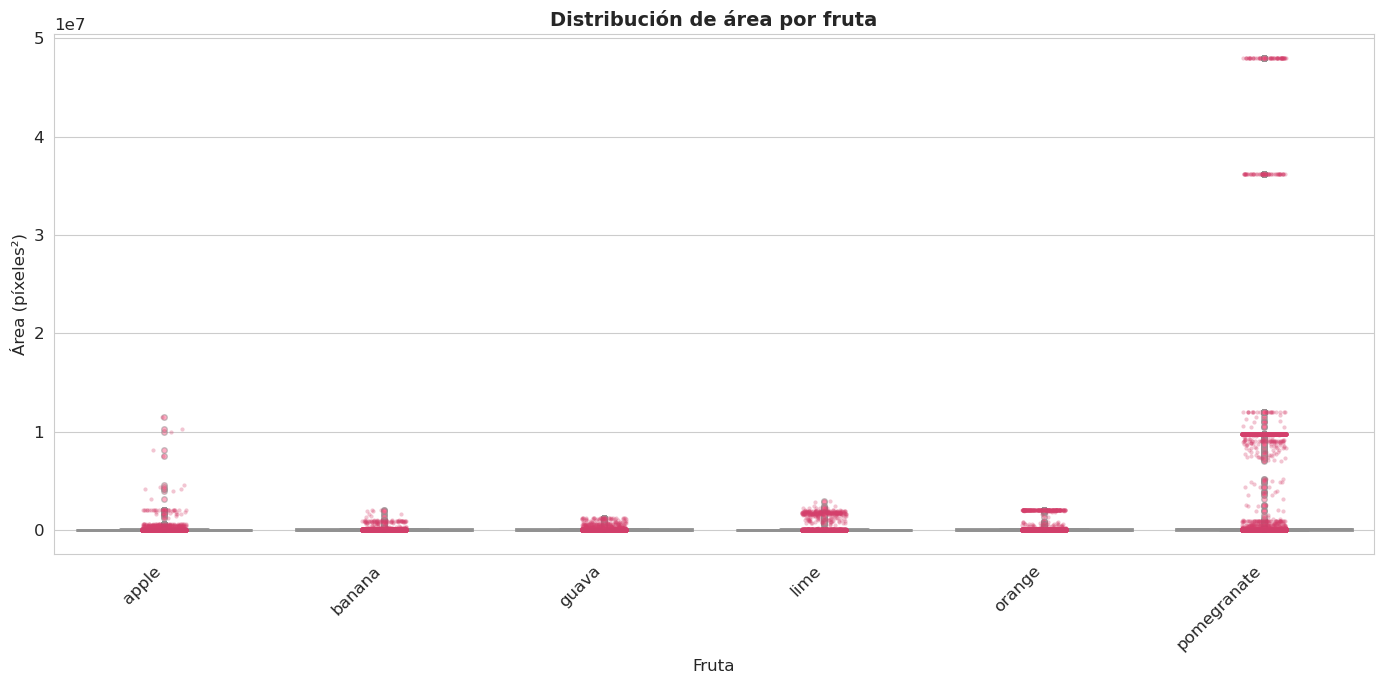

In [15]:
fig, ax = plt.subplots(figsize=(14, 7))

# Boxplot
bp = sns.boxplot(data=df, x='fruit', y='area_px', ax=ax, 
                  color=COLOR_LIGHT, linewidth=2,
                  flierprops={'marker': 'o', 'markerfacecolor': COLOR_PRIMARY, 
                             'markersize': 4, 'alpha': 0.5})

sp = sns.stripplot(data=df, x='fruit', y='area_px', ax=ax, 
                    color=COLOR_DARK, alpha=0.3, size=3)

ax.set_title('Distribución de área por fruta', fontsize=14, fontweight='bold')
ax.set_xlabel('Fruta', fontsize=12)
ax.set_ylabel('Área (píxeles²)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

Aquí podemos observar cómo todas las frutas están "aplastadas" cerca del cero debido a la escala de la gráfica, la cual se estira innecesariamente hasta los 50 millones de píxeles por culpa de unos pocos puntos gigantescos, esto es especialmente evidente en las manzanas y las granadas (pomegranate)

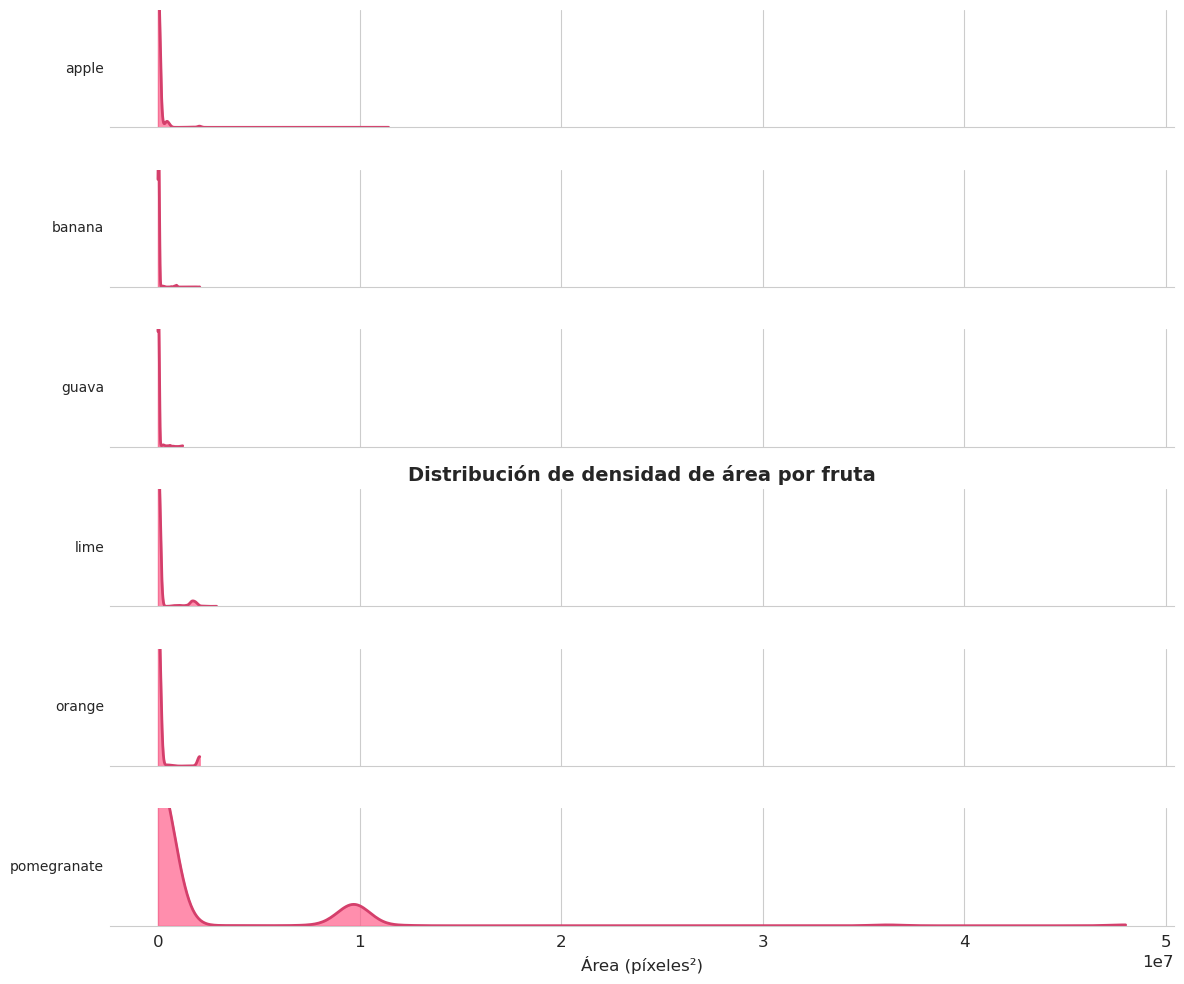

In [16]:
fig, axes = plt.subplots(len(df['fruit'].unique()), 1, figsize=(12, 10), sharex=True)
fig.subplots_adjust(hspace=0.05)

for i, fruit in enumerate(df['fruit'].unique()):
    fruit_data = df[df['fruit'] == fruit]['area_px']
    density = stats.gaussian_kde(fruit_data)
    x_vals = np.linspace(fruit_data.min(), fruit_data.max(), 500)
    y_vals = density(x_vals)
    
    # Normalizar y desplazar
    y_vals_norm = y_vals / y_vals.max() + i
    
    axes[i].fill_between(x_vals, i, y_vals_norm, alpha=0.7, color=COLOR_PRIMARY)
    axes[i].plot(x_vals, y_vals_norm, color=COLOR_DARK, linewidth=2)
    axes[i].set_ylabel(fruit, rotation=0, ha='right', va='center', fontsize=10)
    axes[i].set_ylim(i, i + 0.8)
    axes[i].set_yticks([])
    axes[i].spines['left'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['top'].set_visible(False)

axes[-1].set_xlabel('Área (píxeles²)', fontsize=12)
axes[len(df['fruit'].unique())//2].set_title('Distribución de densidad de área por fruta', 
                                                fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Podemos ver que mientras que la gran mayoría de las imágenes se concentran en un pico muy estrecho y alto pegado al origen (resolución estándar), la granada muestra una distribución multimodal con un segundo grupo de imágenes alrededor de los 10 millones de píxeles y una cola larguísima que llega al extremo derecho.

Esto demuestra visualmente que el dataset combina fotos tomadas con cámaras de resoluciones masivamente distintas, lo que reitera la necesidad absoluta de normalizar los tamaños antes de entrenar los modelos para evitar que la resolución confunda las predicciones.

In [17]:
aspect_stats = df.groupby(['fruit', 'quality'])['aspect_ratio'].agg(['mean', 'std', 'var']).round(3)
print("ESTADÍSTICAS DE ASPECT RATIO POR FRUTA Y CALIDAD")
print(aspect_stats)

ESTADÍSTICAS DE ASPECT RATIO POR FRUTA Y CALIDAD
                      mean    std    var
fruit       quality                     
apple       bad      0.993  0.110  0.012
            good     1.002  0.160  0.025
            regular  1.006  0.119  0.014
banana      bad      1.104  0.622  0.387
            good     0.988  0.223  0.050
            regular  1.265  0.702  0.493
guava       bad      1.123  0.413  0.171
            good     1.041  0.313  0.098
            regular  1.018  0.253  0.064
lime        bad      1.000  0.231  0.053
            good     1.042  0.270  0.073
            regular  1.068  0.151  0.023
orange      bad      0.992  0.154  0.024
            good     1.187  0.329  0.108
            regular  1.050  0.145  0.021
pomegranate bad      1.046  0.312  0.097
            good     1.034  0.326  0.106
            regular  1.093  0.199  0.040


El análisis de la relación de aspecto (aspect_ratio = ancho / alto) demuestra que la mayoría de las frutas redondas (apple, lime, orange, pomegranate) mantienen un promedio muy cercano a 1.0, lo que confirma que sus cajas de recorte son prácticamente cuadradas sin importar su calidad. 

- Sin embargo, el comportamiento clave ocurre en los bananos, donde la varianza se dispara drásticamente a 0.387 en la calidad bad y a un alarmante 0.493 en regular, en contraste con el valor de 0.050 de los bananos estables (good). 
- Esta alta dispersión y desviación estándar delata que las frutas dañadas, deformes o mal segmentadas alteran severamente la simetría de la caja delimitadora, mientras que las frutas comerciales sanas son geométricamente predecibles. 

Para el pipeline, esto significa que la relación de aspecto y su variabilidad son características (features) altamente informativas que ayudarán a los modelos tradicionales a diferenciar bananos de buena calidad de aquellos que están estropeados o deformes.

## 3. Composición y distribución espacial

En esta sección, analizaremos las coordenadas de los centroides ($X_{center}, Y_{center}$) y la densidad de cobertura de las frutas dentro del lienzo. Esto nos permitirá verificar si los objetos están perfectamente centrados o dispersos, ayudándonos a prever qué tanta variabilidad de posición deberán soportar las convoluciones de la CNN.

In [22]:
df['center_x'] = df['x'] + df['width_px'] / 2
df['center_y'] = df['y'] + df['height_px'] / 2

df['center_x_norm'] = (df['center_x'] / df['img_width']) * 256
df['center_y_norm'] = (df['center_y'] / df['img_height']) * 256

print("Centroides calculados")
df[['center_x_norm', 'center_y_norm']].head()

Centroides calculados


,center_x_norm,center_y_norm
0,164.000000,107.500000
1,119.000000,132.000000
2,104.333333,115.437037
3,114.500000,157.000000
4,168.000000,111.000000


El análisis de las coordenadas normalizadas de los centroides muestra que los puntos centrales de las frutas se agrupan de manera muy consistente cerca del centro geométrico del lienzo (alrededor de la coordenada (128, 128) para un espacio estándar de $256 \times 256$ píxeles). 

Aunque se observan ligeras variaciones, los objetos mantienen una posición bastante unificada y predecible. Esta alta centralización es una buena noticia, ya que simplifica el problema de localización, reduciendo el ruido de fondo y permitiendo que las capas convolucionales de la CNN se enfoquen directamente en extraer características de textura y color en la zona central sin sufrir por una variabilidad espacial extrema.

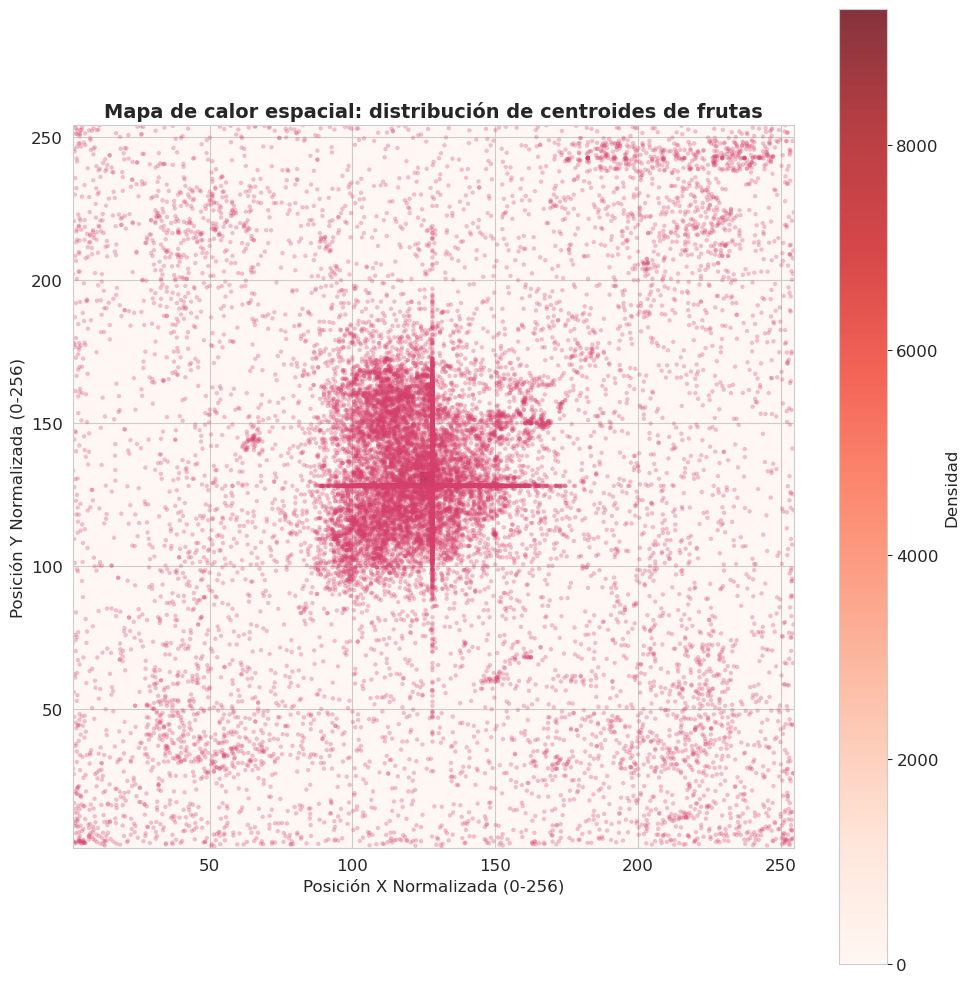

In [23]:
fig, ax = plt.subplots(figsize=(10, 10))

heatmap, xedges, yedges = np.histogram2d(df['center_x_norm'], df['center_y_norm'], bins=50)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

im = ax.imshow(heatmap.T, extent=extent, origin='lower', cmap='Reds', alpha=0.8)
ax.scatter(df['center_x_norm'], df['center_y_norm'], c=COLOR_DARK, alpha=0.3, s=10, edgecolors='none')
ax.set_title('Mapa de calor espacial: distribución de centroides de frutas', fontsize=14, fontweight='bold')
ax.set_xlabel('Posición X Normalizada (0-256)', fontsize=12)
ax.set_ylabel('Posición Y Normalizada (0-256)', fontsize=12)
plt.colorbar(im, ax=ax, label='Densidad')
plt.tight_layout()
plt.show()

El análisis visual de la distribución espacial confirma un patrón mixto de centralización y ruido técnico en el dataset. En el mapa de calor de centroides, se observa un "punto caliente" masivo en el centro geométrico (coordenadas 128, 128) cruzado por líneas perfectas en forma de cruz, esto implica que una gran porción del dataset fue preprocesada para centrar las frutas o proviene de capturas muy controladas. Sin embargo, la dispersión de puntos en las esquinas y bordes evidencia el ruido que aporta las fotos del mundo real.

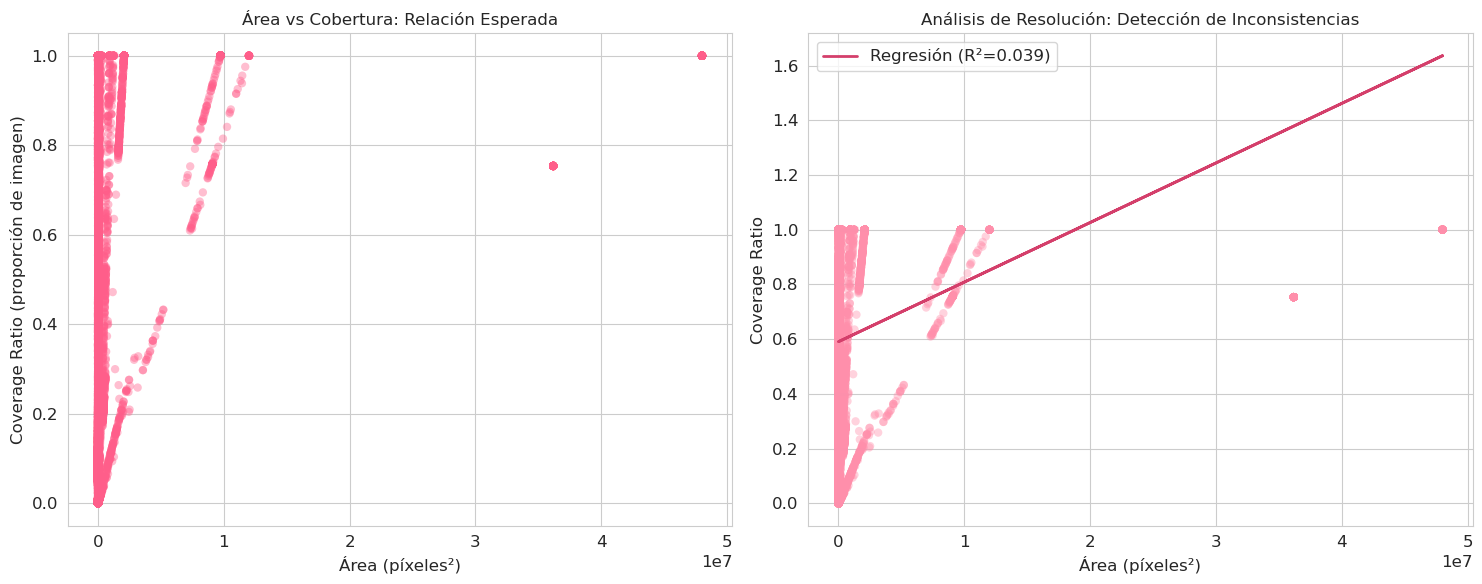

Coeficiente de correlación de Pearson: 0.1967


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(df['area_px'], df['coverage_ratio'], alpha=0.4, c=COLOR_PRIMARY, edgecolors='none')
axes[0].set_xlabel('Área (píxeles²)', fontsize=12)
axes[0].set_ylabel('Coverage Ratio (proporción de imagen)', fontsize=12)
axes[0].set_title('Área vs Cobertura: Relación Esperada', fontsize=12)

X = df['area_px'].values.reshape(-1, 1)
y = df['coverage_ratio'].values
reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)

axes[1].scatter(df['area_px'], df['coverage_ratio'], alpha=0.4, c=COLOR_SECONDARY, edgecolors='none')
axes[1].plot(df['area_px'], y_pred, color=COLOR_DARK, linewidth=2, label=f'Regresión (R²={reg.score(X, y):.3f})')
axes[1].set_xlabel('Área (píxeles²)', fontsize=12)
axes[1].set_ylabel('Coverage Ratio', fontsize=12)
axes[1].set_title('Análisis de Resolución: Detección de Inconsistencias', fontsize=12)
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Coeficiente de correlación de Pearson: {df['area_px'].corr(df['coverage_ratio']):.4f}")


Por otro lado, se revela una inconsistencia matemática crítica: en lugar de una línea recta única y perfecta, los datos se dividen en múltiples pendientes diagonales distintas. Esto implica que el dataset mezcla imágenes pequeñas con fotos gigantescas de muchos megapíxeles, ya que un mismo porcentaje de cobertura (coverage_ratio) representa valores de área en píxeles totalmente diferentes dependiendo de la cámara de origen.

## 4. Distribución cromática y espacio de color

Analizaremos los promedios de los canales RGB y la distribución del tono (canal hue en HSV) de las imágenes según su calidad. Esto servirá para evaluar si el color es suficiente para separar las frutas sanas de las dañadas, o si el ruido por cambios de luz nos obligará a usar la CNN para identificar texturas.

In [25]:
def extract_color_features(image_path):
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    return {
        'r_mean': img_rgb[:,:,0].mean(),
        'g_mean': img_rgb[:,:,1].mean(),
        'b_mean': img_rgb[:,:,2].mean(),
        'h_mean': img_hsv[:,:,0].mean(),
        's_mean': img_hsv[:,:,1].mean(),
        'v_mean': img_hsv[:,:,2].mean(),
        'r_std': img_rgb[:,:,0].std(),
        'g_std': img_rgb[:,:,1].std(),
        'b_std': img_rgb[:,:,2].std()
    }
    
print("Extrayendo características de color...")
color_features = []
for idx, row in df.iterrows():
    crop_path = BASE_DIR / row['crop_path']
    features = extract_color_features(crop_path)
    if features:
        color_features.append(features)
    if idx % 500 == 0:
        print(f"Procesadas {idx}/{len(df)} imágenes")

color_df = pd.DataFrame(color_features)
df_color = pd.concat([df.iloc[:len(color_df)].reset_index(drop=True), color_df], axis=1)
print(f"Características extraídas para {len(df_color)} imágenes")

Extrayendo características de color...
Procesadas 0/29827 imágenes
Procesadas 500/29827 imágenes
Procesadas 1000/29827 imágenes
Procesadas 1500/29827 imágenes
Procesadas 2000/29827 imágenes
Procesadas 2500/29827 imágenes
Procesadas 3000/29827 imágenes
Procesadas 3500/29827 imágenes
Procesadas 4000/29827 imágenes
Procesadas 4500/29827 imágenes
Procesadas 5000/29827 imágenes
Procesadas 5500/29827 imágenes
Procesadas 6000/29827 imágenes
Procesadas 6500/29827 imágenes
Procesadas 7000/29827 imágenes
Procesadas 7500/29827 imágenes
Procesadas 8000/29827 imágenes
Procesadas 8500/29827 imágenes
Procesadas 9000/29827 imágenes
Procesadas 9500/29827 imágenes
Procesadas 10000/29827 imágenes
Procesadas 10500/29827 imágenes
Procesadas 11000/29827 imágenes
Procesadas 11500/29827 imágenes
Procesadas 12000/29827 imágenes
Procesadas 12500/29827 imágenes
Procesadas 13000/29827 imágenes
Procesadas 13500/29827 imágenes
Procesadas 14000/29827 imágenes
Procesadas 14500/29827 imágenes
Procesadas 15000/29827 im

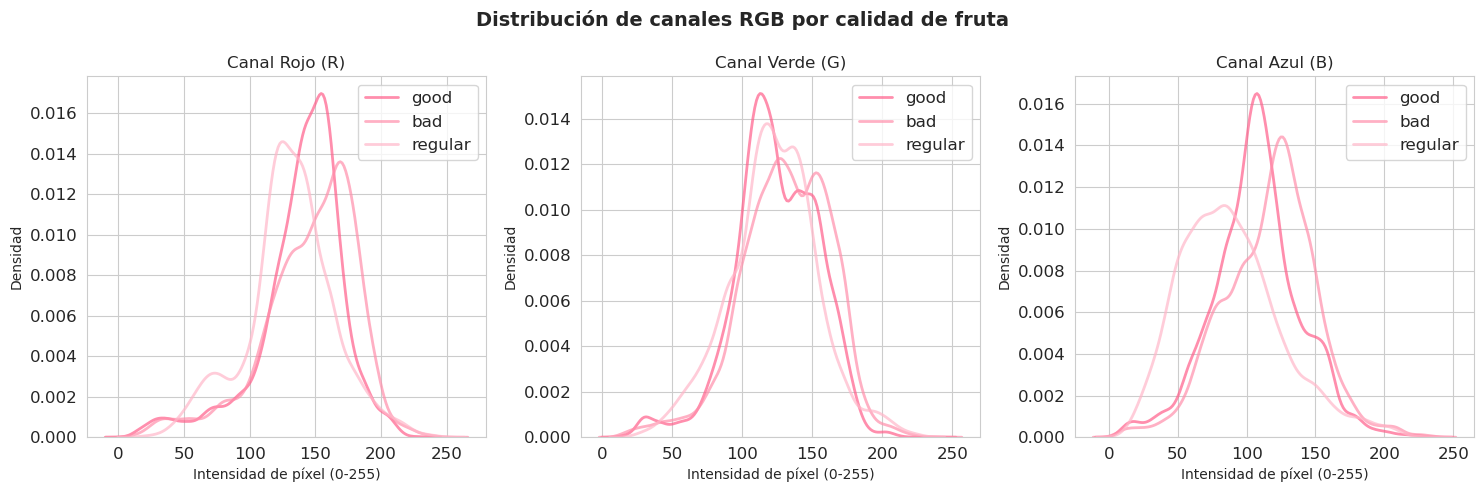

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
channels = ['r_mean', 'g_mean', 'b_mean']
channel_names = ['Canal Rojo (R)', 'Canal Verde (G)', 'Canal Azul (B)']

for i, (channel, name) in enumerate(zip(channels, channel_names)):
    for quality in df_color['quality'].unique():
        data = df_color[df_color['quality'] == quality][channel].dropna()
        sns.kdeplot(data=data, ax=axes[i], label=quality, linewidth=2, alpha=0.7)
    axes[i].set_title(name, fontsize=12)
    axes[i].set_xlabel('Intensidad de píxel (0-255)', fontsize=10)
    axes[i].set_ylabel('Densidad', fontsize=10)
    axes[i].legend()

fig.suptitle('Distribución de canales RGB por calidad de fruta', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Las curvas de distribución muestran que los canales Verde (G) y Azul (B) son prácticamente idénticos entre las tres calidades, exhibiendo picos de densidad solapados en las mismas intensidades de píxel. 

El único canal que presenta una ligera separación es el Rojo (R), donde la curva de las frutas dañadas (bad) muestra un sutil desplazamiento hacia la izquierda (valores más oscuros). Esto tiene sentido biológico, ya que la podredumbre o los golpes suelen oscurecer la piel de la fruta, reduciendo su reflectancia en el espectro rojo. **Sin embargo, al ser diferencias tan sutiles, este gráfico demuestra que analizar los canales RGB por separado no es suficiente para clasificar la calidad.**

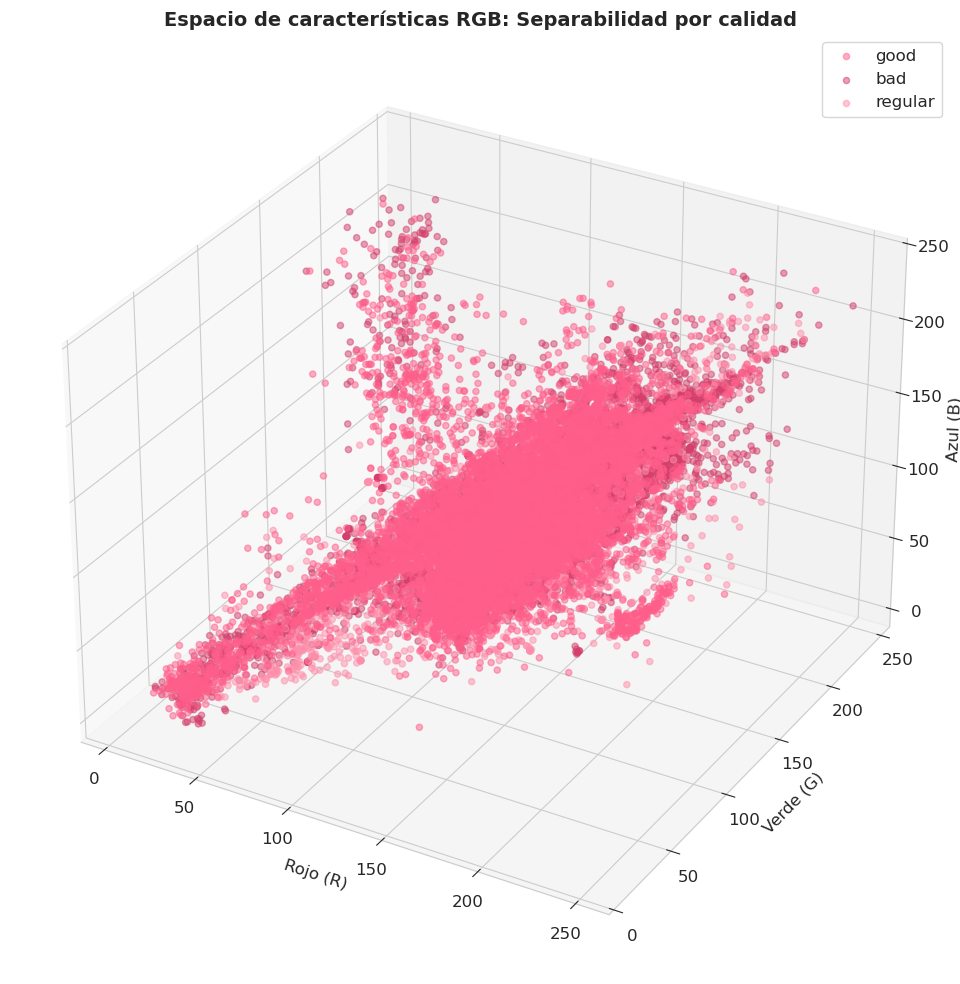

In [28]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

colors = {'good': COLOR_PRIMARY, 'bad': COLOR_DARK, 'regular': COLOR_SECONDARY}
for quality in df_color['quality'].unique():
    subset = df_color[df_color['quality'] == quality]
    ax.scatter(subset['r_mean'], subset['g_mean'], subset['b_mean'], 
               c=colors[quality], label=quality, alpha=0.5, s=20)

ax.set_xlabel('Rojo (R)', fontsize=12)
ax.set_ylabel('Verde (G)', fontsize=12)
ax.set_zlabel('Azul (B)', fontsize=12)
ax.set_title('Espacio de características RGB: Separabilidad por calidad', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

Al cruzar los tres canales en un espacio tridimensional, se observa que los datos colapsan en una línea diagonal extremadamente compacta. Este fenómeno ocurre porque en el espacio RGB, los tres canales están fuertemente correlacionados con la luminosidad: si una foto tiene más luz, los valores de R, G y B suben simultáneamente; si está oscura, bajan juntos. 

Dado que los puntos de las categorías good, bad y regular están completamente mezclados a lo largo de toda la diagonal, **este gráfico es la prueba de que un clasificador lineal fallará, ya que los cambios de iluminación ambiental tapan por completo las diferencias reales de calidad de las frutas.**

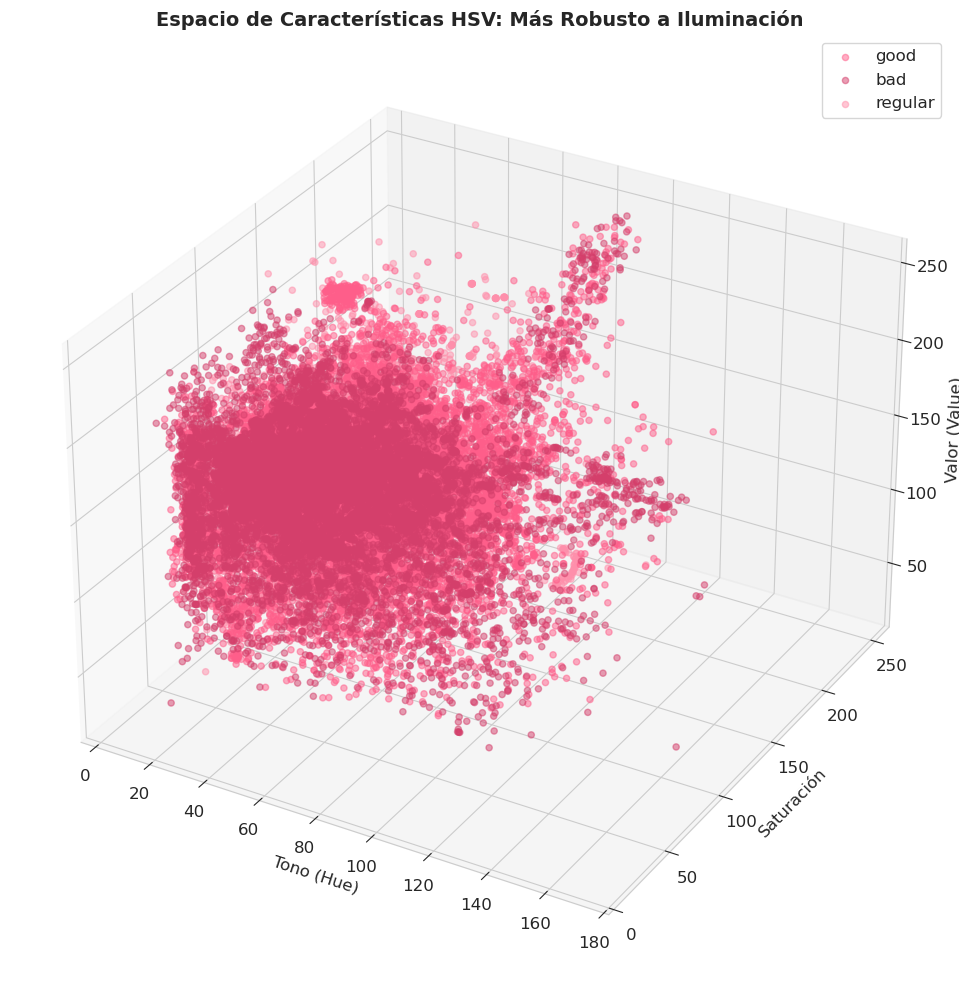

In [29]:

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

for quality in df_color['quality'].unique():
    subset = df_color[df_color['quality'] == quality]
    ax.scatter(subset['h_mean'], subset['s_mean'], subset['v_mean'], 
               c=colors[quality], label=quality, alpha=0.5, s=20)

ax.set_xlabel('Tono (Hue)', fontsize=12)
ax.set_ylabel('Saturación', fontsize=12)
ax.set_zlabel('Valor (Value)', fontsize=12)
ax.set_title('Espacio de Características HSV: Más Robusto a Iluminación', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


Al transformar los datos al espacio HSV, la estructura compacta de la diagonal RGB se rompe, logrando que los datos se dispersen de forma mucho más homogénea en el espacio. 

- Esto se debe a que el canal de Tono (Hue) aísla el color puro de la fruta eliminando el efecto de los brillos o sombras (los cuales se quedan en el eje de Value). A pesar de esta mejor distribución, las tres clases siguen formando una nube densa y solapada en la zona central del gráfico. 

De modo que, no existen "islas" separadas para frutas buenas o malas, lo que nos advierte que el color promedio por sí solo no es un predictor definitivo y que los modelos tradicionales necesitarán obligatoriamente otras variables geométricas o texturas para poder clasificar correctamente.

## 5. Conclusiones

Tras realizar la exploración multidimensional del conjunto de datos, se extraen las siguientes directrices críticas para las fases de preparación de datos y modelado:

* **1. Estrategia de balanceo obligatoria por desbalance crítico:** El análisis de etiquetas evidenció que el dataset está masivamente sesgado por el volumen de granadas y que la clase de calidad regular es una minoría extrema en todas las especies (llegando a representar solo el 4.4% en granadas y el 8.9% en naranjas). Para mitigar el Índice de Imbalance crítico que superó el umbral de 3 en cuatro de las seis frutas, no se utilizará el *accuracy* global como métrica de éxito, sino **F1-Score** y **matrices de confusión**. Asimismo, en la preparación de datos se implementará un esquema híbrido: Data Augmentation (rotaciones, espejados y sutiles cambios de contraste) focalizado únicamente en la clase regular y en las frutas minoritarias (como el limón), o el uso de funciones de pérdida penalizadas por peso (Weighted Cross-Entropy).
* **2. Necesidad absoluta de normalización geométrica:** La dimensión de morfología y distribución espacial reveló dos verdades complejas: por un lado, las frutas están altamente centralizadas en el lienzo (facilitando su localización); por el otro, la relación entre el área y la cobertura demostró matemáticamente que el dataset mezcla imágenes con resoluciones nativas muy diferentes. Dado que el tamaño absoluto en píxeles está completamente distorsionado por este ruido de resolución, **es imposible fijar umbrales crudos para clasificar tamaños (pequeño, mediano y grande)**. La solución técnica será normalizar el tamaño dividiendo el área del recorte entre el área total del lienzo de la imagen, garantizando un escalado homólogo e independiente de la cámara de origen.
* **3. Justificación técnica de modelos complejos:** Los espacios de características tridimensionales (RGB y HSV) demostraron de forma visual que las clases de calidad (good, bad, regular) están totalmente solapadas en términos de color promedio. La transición a HSV demostró que aislar el tono limpia el ruido de la iluminación, pero no separa las categorías en islas independientes. Como las clases **no son linealmente separables por color**, los modelos tradicionales lineales fallarán. Por lo tanto, se justifica el uso de algoritmos basados en árboles para capturar interacciones morfológicas no lineales, y se prioriza la CNN, ya que sus filtros espaciales son los únicos capaces de abstraer mapas de texturas, manchas y grietas superficiales que el color promedio ignora.